Problem 7

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
import torch.optim as optim
from torchvision.transforms import transforms
from torchvision.utils import save_image

import numpy as np
import matplotlib.pyplot as plt

In [2]:
lr = 0.001
batch_size = 100
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Step I

In [3]:
# MNIST dataset
dataset = datasets.MNIST(root='./mnist_data/',
                               train=True, 
                               transform=transforms.ToTensor(),
                               download=True)

train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [50000, 10000])

test_dataset = datasets.MNIST(root='./mnist_data/',
                              train=False, 
                              transform=transforms.ToTensor())

# KMNIST dataset, only need test dataset
anomaly_dataset = datasets.KMNIST(root='./kmnist_data/',
                              train=False, 
                              transform=transforms.ToTensor(),
                              download=True)

# print(len(train_dataset))  # 50000
# print(len(validation_dataset))  # 10000
# print(len(test_dataset))  # 10000
# print(len(anomaly_dataset))  # 10000

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

...

Extracting ./kmnist_data/KMNIST/raw/train-labels-idx1-ubyte.gz to ./kmnist_data/KMNIST/raw



  0%|          | 0/3041136 [00:00<?, ?it/s]

Extracting ./kmnist_data/KMNIST/raw/t10k-images-idx3-ubyte.gz to ./kmnist_data/KMNIST/raw



  0%|          | 0/5120 [00:00<?, ?it/s]

Extracting ./kmnist_data/KMNIST/raw/t10k-labels-idx1-ubyte.gz to ./kmnist_data/KMNIST/raw



Step II : AutoEncoder

In [4]:
# Define Encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 32)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        z = F.relu(self.fc3(x))
        return z

# Define Decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 784)
    def forward(self, z):
        z = F.relu(self.fc1(z))
        z = F.relu(self.fc2(z))
        x = F.sigmoid(self.fc3(z))  # to make output's pixels are 0~1
        x = x.view(x.size(0), 1, 28, 28) 
        return x

Step III : Instantiate model & define loss and optimizer

In [5]:
enc = Encoder().to(device)
dec = Decoder().to(device)
loss_function = nn.MSELoss()
optimizer = optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=lr)

Step IV : Training

0th epoch starting.


/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


1th epoch starting.
2th epoch starting.
3th epoch starting.
4th epoch starting.
5th epoch starting.
6th epoch starting.
7th epoch starting.
8th epoch starting.
9th epoch starting.
Time ellapsed in training is: 99.13060545921326


Decoder(
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
)

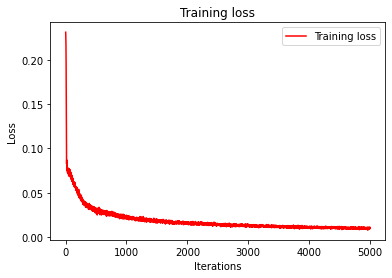

In [6]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


train_loss_list = []

import time
start = time.time()
for epoch in range(epochs) :
    print("{}th epoch starting.".format(epoch))
    enc.train()
    dec.train()
    for batch, (images, _) in enumerate(train_loader) :
        images = images.to(device)
        z = enc(images)
        reconstructed_images = dec(z)
        
        optimizer.zero_grad()
        train_loss = loss_function(images, reconstructed_images)
        train_loss.backward()
        train_loss_list.append(train_loss.item())

        optimizer.step()

        print(f"[Epoch {epoch:3d}] Processing batch #{batch:3d} reconstruction loss: {train_loss.item():.6f}", end='\r')
end = time.time()
print("Time ellapsed in training is: {}".format(end - start))

# plotting train loss
plt.plot(range(1,len(train_loss_list)+1), train_loss_list, 'r', label='Training loss')
plt.title('Training loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss.png')

enc.eval()
dec.eval()

Step V : Calculate standard deviation by using validation set

In [7]:
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=batch_size)

scores = []

for images, _ in validation_loader:
  images = images.to(device)
  z = enc(images)
  reconstructed_images = dec(z)
  score = loss_function(images, reconstructed_images) 
  scores.append(score.item())

scores = torch.Tensor(scores)
mean = torch.mean(scores)
std = torch.std(scores)

threshold = mean + 3 * std
print("threshold: ", threshold.tolist())

/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


threshold:  0.012076077982783318


Step VI : Anomaly detection (MNIST)

In [8]:
exact = 0
dismatch = 0

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size)

for images, _ in test_loader:
  images = images.to(device)
  z = enc(images)
  reconstructed_images = dec(z)
  score = loss_function(images, reconstructed_images)

  if score > threshold:
    dismatch += 1
  else:
    exact += 1

print(f"Type I error rate(MNIST Dataset) is {dismatch/(dismatch+exact)}")

/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Type I error rate(MNIST Dataset) is 0.03


Step VII : Anomaly detection (KMNIST)

In [9]:
exact = 0
dismatch = 0

anomaly_loader = torch.utils.data.DataLoader(dataset=anomaly_dataset, batch_size=batch_size)

for images, _ in anomaly_loader:
  images = images.to(device)
  z = enc(images)
  reconstructed_images = dec(z)
  score = loss_function(images, reconstructed_images)

  if score > threshold:
    dismatch += 1
  else:
    exact += 1

print(f"Type II error rate(KMNIST Dataset) is {exact/(dismatch+exact)}")

/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


Type II error rate(KMNIST Dataset) is 0.0
